In [ ]:
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

Saving ahok_label_with_string (2).csv to ahok_label_with_string (2).csv


In [ ]:
df = pd.read_csv('ahok_label_with_string (2).csv', sep=';')
print(df.columns) # Periksa kolom yang ada
# Pilih kolom yang akan digunakan (tweet_string dan label_manual)
# Perhatikan bahwa ada kolom dengan nama yang mirip (tweet_clean dan Tweet_clean)
df = df[['tweet_string', 'label_manual']]
df.columns = ['text', 'label']  # Ubah nama kolom untuk konsistensi

Index(['tweet_clean', 'Tweet_clean', 'tweet_string', 'label_manual'], dtype='object')


In [ ]:
df.head(10)

,text,label
0,'ahok' 'the' 'best' 'mulyono',negatif
1,'ahok' 'utk' 'uji' 'orang' 'ilah' 'jabat' 'yg'...,negatif
2,'ahok' 'yg' 'salah',negatif
3,'jagung' 'dpr' 'kemen' 'bumn' 'panggil' 'aja' ...,negatif
4,'orang' 'yg' 'yg' 'teriak' 'cina' 'kafir' 'aho...,negatif
5,'tidur' 'udah' 'merem' 'pikir' 'kodok' 'balik'...,negatif
6,'abis' 'nonton' 'waktu' 'sahur' 'wkwk' 'gilee'...,negatif
7,'acara' 'cabul' 'si' 'hph' 'dukung' 'bela' 'ko...,negatif
8,'action' 'keluh' 'pidato' 'rakyat' 'bosan' 'ni...,negatif
9,'adeknya' 'ahok',positif


# **Import Library**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Unduh resource NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# **Pemrosesan Teks**

In [ ]:
# Preprocessing teks
def preprocess_text(text):
    text = text.strip("'")   # Hapus tanda kutip dan karakter khusus

    tokens = word_tokenize(text)    # Tokenisasi
    tokens = [word.lower() for word in tokens]    # Konversi ke lowercase

    # Hapus tanda baca
    table = str.maketrans('', '', string.punctuation)
    tokens = [word.translate(table) for word in tokens]

    # Hapus stopwords
    stop_words = set(stopwords.words('indonesian') + stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Hapus token yang bukan alphabetic
    tokens = [word for word in tokens if word.isalpha()]

    return ' '.join(tokens)

# Terapkan preprocessing
df['processed_text'] = df['text'].apply(preprocess_text)

# **Output Pemrosesan Teks**

In [ ]:
df.head(10)

,text,label,processed_text
0,'ahok' 'the' 'best' 'mulyono',negatif,ahok best mulyono
1,'ahok' 'utk' 'uji' 'orang' 'ilah' 'jabat' 'yg'...,negatif,ahok utk uji orang ilah jabat yg habis pikir k...
2,'ahok' 'yg' 'salah',negatif,ahok yg salah
3,'jagung' 'dpr' 'kemen' 'bumn' 'panggil' 'aja' ...,negatif,jagung dpr kemen bumn panggil aja ahok ga bera...
4,'orang' 'yg' 'yg' 'teriak' 'cina' 'kafir' 'aho...,negatif,orang yg yg teriak cina kafir ahok trs ngomong...
5,'tidur' 'udah' 'merem' 'pikir' 'kodok' 'balik'...,negatif,tidur udah merem pikir kodok kodok wow wow koh...
6,'abis' 'nonton' 'waktu' 'sahur' 'wkwk' 'gilee'...,negatif,abis nonton sahur wkwk gilee ahok nyala ya mog...
7,'acara' 'cabul' 'si' 'hph' 'dukung' 'bela' 'ko...,negatif,acara cabul si hph dukung bela koruptor ya mar...
8,'action' 'keluh' 'pidato' 'rakyat' 'bosan' 'ni...,negatif,action keluh pidato rakyat bosan nih kasihtau ...
9,'adeknya' 'ahok',positif,adeknya ahok


# **Inisialisasi Decision Tree**

In [ ]:
# Pisahkan data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_text'],
    df['label'],
    test_size=0.2,
    random_state=42
)

# Ekstraksi fitur dengan TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Inisialisasi Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=2, criterion='gini')

# Latih model
dt_classifier.fit(X_train_tfidf, y_train)

# Prediksi
y_pred = dt_classifier.predict(X_test_tfidf)

# Evaluasi
print("Accuracy Model:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Model: 0.8930817610062893

Classification Report:
              precision    recall  f1-score   support

     negatif       0.94      0.94      0.94       146
     positif       0.36      0.38      0.37        13

    accuracy                           0.89       159
   macro avg       0.65      0.66      0.66       159
weighted avg       0.90      0.89      0.89       159



# **Implementasi Model Pada Sentimen Baru**

In [ ]:
# Fungsi untuk memprediksi sentimen baru
def predict_sentiment(text):
    # Preprocessing
    processed_text = preprocess_text(text)
    # Transformasi teks ke bentuk TF-IDF
    processed_tfidf = vectorizer.transform([processed_text])
    # Prediksi dengan model decision tree
    prediction = dt_classifier.predict(processed_tfidf)

    return prediction[0]

# Contoh penggunaan
sample_text = "ahok orang baik dan jujur"
print(f"\nPrediksi untuk '{sample_text}': {predict_sentiment(sample_text)}")

sample_text = "ahok busuk dan korup"
print(f"Prediksi untuk '{sample_text}': {predict_sentiment(sample_text)}")



Prediksi untuk 'ahok orang baik dan jujur': positif
Prediksi untuk 'ahok busuk dan korup': negatif


# **Visualisasi Decision Tree**

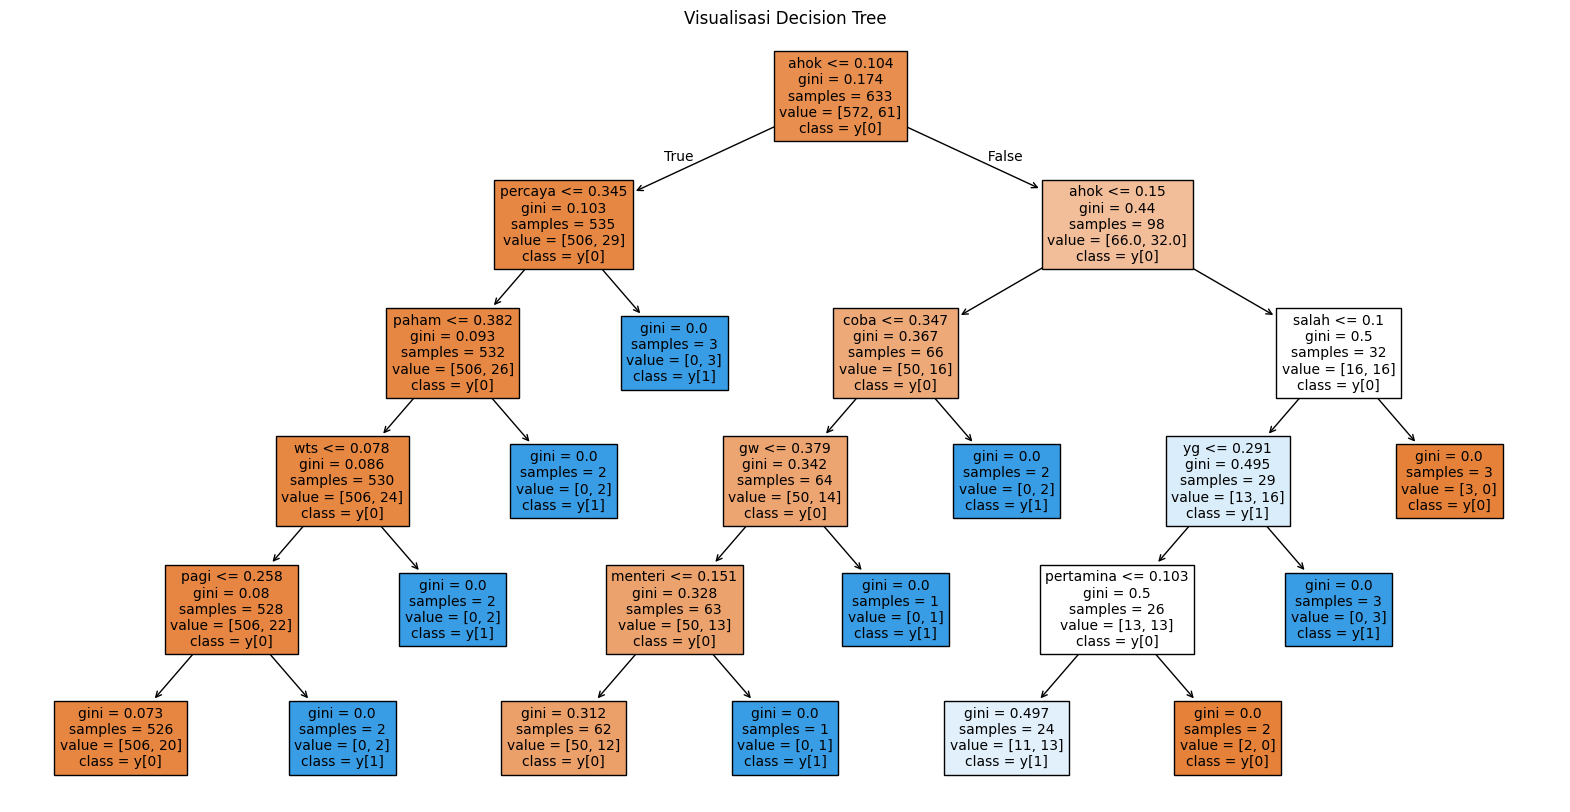

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt_classifier, filled=True, fontsize=10, feature_names=vectorizer.get_feature_names_out(), class_names=True)
plt.title("Visualisasi Decision Tree")
plt.show()

# **Melihat kata-kata paling berpengaruh dalam model:**

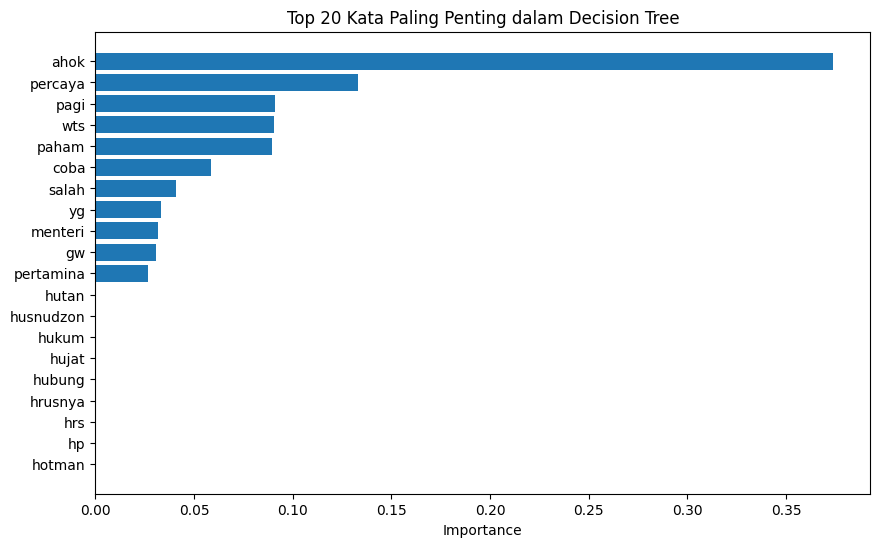

In [ ]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
importances = dt_classifier.feature_importances_

# Ambil 20 fitur terpenting
indices = np.argsort(importances)[::-1][:20]

# Visualisasi
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance')
plt.title('Top 20 Kata Paling Penting dalam Decision Tree')
plt.gca().invert_yaxis()
plt.show()


# **Untuk melihat performa klasifikasi lebih detail:**

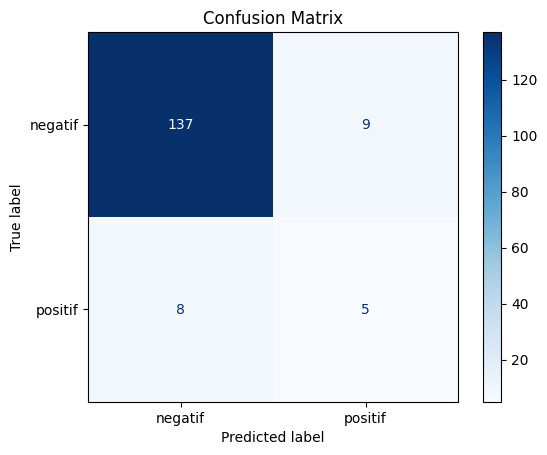

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

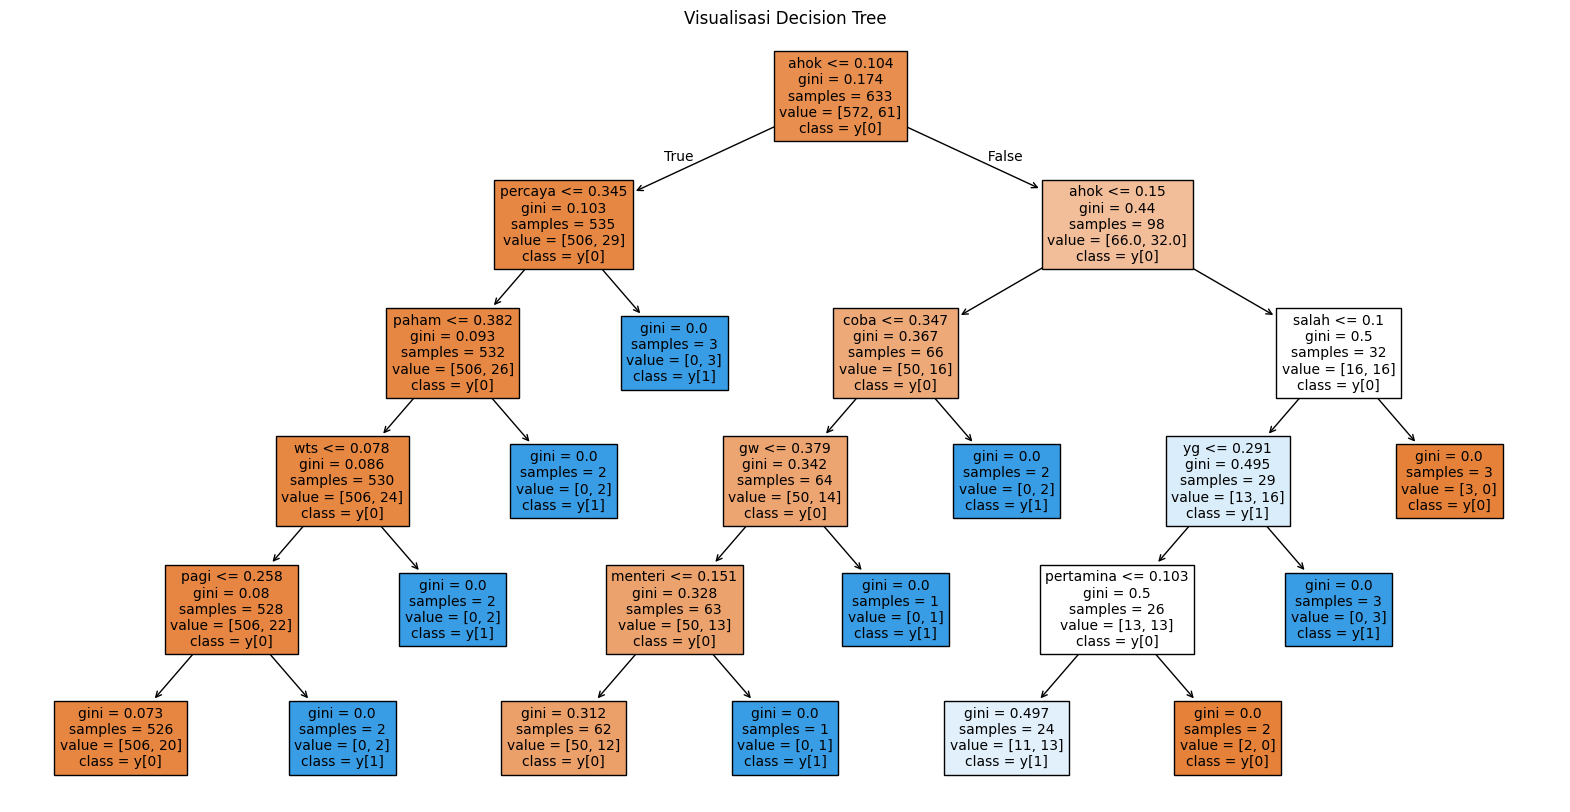

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt_classifier, filled=True, fontsize=10, feature_names=vectorizer.get_feature_names_out(), class_names=True)
plt.title("Visualisasi Decision Tree")
plt.show()

# **Menaikkan Akurasi**

### 1. Preprocessing Teks (Tingkatkan Kualitas Teks Input)

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 1.1 MB/s eta 0:00:00


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('punkt')
nltk.download('stopwords')

factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Fungsi preprocessing dengan stemming
def preprocess_text(text):
    text = text.strip("'")

    #tokenizing(n-gram)
    tokens = word_tokenize(text)

    #casefolding
    tokens = [word.lower() for word in tokens]

    table = str.maketrans('', '', string.punctuation)
    tokens = [word.translate(table) for word in tokens]

    #stopword
    stop_words = set(stopwords.words('indonesian') + stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [word for word in tokens if word.isalpha()]

    #stemming
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(stemmed_tokens)

# Terapkan ulang preprocessing
df['processed_text'] = df['text'].apply(preprocess_text)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#Latih ulang model setelah preprocessing baru ini:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_text'], df['label'], test_size=0.2, random_state=42)

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Model
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_classifier.fit(X_train_tfidf, y_train)

# Evaluasi
y_pred = dt_classifier.predict(X_test_tfidf)
print("✅ Akurasi setelah ASPEK 1 (Stemming):", accuracy_score(y_test, y_pred))


✅ Akurasi setelah ASPEK 1 (Stemming): 0.89937106918239


### 2. Tuning Parameter Decision Tree

In [ ]:
from sklearn.model_selection import GridSearchCV

# Grid parameter
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# GridSearchCV
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_tfidf, y_train)

# Model terbaik
best_dt = grid.best_estimator_

# Evaluasi
y_pred = best_dt.predict(X_test_tfidf)
print("✅ Akurasi setelah ASPEK 2 (Tuning Parameter):", accuracy_score(y_test, y_pred))
print("Parameter terbaik:", grid.best_params_)

✅ Akurasi setelah ASPEK 2 (Tuning Parameter): 0.8930817610062893
Parameter terbaik: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}


**Evaluasi per nilai max_depthl**

In [ ]:
print("🔍 Evaluasi `max_depth` (dengan min_samples_split=2 dan criterion='gini'):")
for depth in [10]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=2,
        criterion='gini',
        random_state=42
    )
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    print(f"max_depth = {depth:<2} → Akurasi = {acc:.4f}")


🔍 Evaluasi `max_depth` (dengan min_samples_split=2 dan criterion='gini'):
max_depth = 10 → Akurasi = 0.8805


**Evaluasi per nilai min_samples_split**

In [ ]:
print("\n🔍 Evaluasi `min_samples_split` (dengan max_depth=10 dan criterion='gini'):")
for split in [5]:
    model = DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=split,
        criterion='gini',
        random_state=42
    )
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    print(f"min_samples_split = {split:<2} → Akurasi = {acc:.4f}")


🔍 Evaluasi `min_samples_split` (dengan max_depth=10 dan criterion='gini'):
min_samples_split = 5  → Akurasi = 0.8805


**Evaluasi per nilai criterion**

In [ ]:
print("\n🔍 Evaluasi `criterion` (dengan max_depth=10 dan min_samples_split=5):")
for crit in ['entropy']:
    model = DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=5,
        criterion=crit,
        random_state=42
    )
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    print(f"criterion = {crit:<7} → Akurasi = {acc:.4f}")


🔍 Evaluasi `criterion` (dengan max_depth=10 dan min_samples_split=5):
criterion = entropy → Akurasi = 0.8994


### Aspek 3: Validasi Model (Cross-Validation)

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Gunakan model terbaik dari hasil tuning (aspek 2)
cv_scores = cross_val_score(best_dt, X_train_tfidf, y_train, cv=5, scoring='accuracy')

print("✅ Akurasi setelah ASPEK 3 (Cross Validation):")
print("Akurasi per fold:", cv_scores)
print("Rata-rata akurasi:", np.mean(cv_scores))

✅ Akurasi setelah ASPEK 3 (Cross Validation):
Akurasi per fold: [0.88976378 0.8976378  0.8976378  0.88888889 0.8968254 ]
Rata-rata akurasi: 0.8941507311586051


### Aspek 4: Feature Selection

In [ ]:
from sklearn.metrics import accuracy_score

# Ambil importance dari model
importances = best_dt.feature_importances_
feature_names = vectorizer.get_feature_names_out()

# Tampilkan jumlah fitur awal
print("Jumlah fitur awal (TF-IDF):", len(feature_names))

# Ambil indeks fitur yang penting (bukan nol)
important_indices = np.where(importances > 0)[0]
important_features = feature_names[important_indices]

# Tampilkan jumlah fitur setelah seleksi
print("Jumlah fitur setelah Feature Selection:", len(important_features))

# Buat ulang vectorizer dengan fitur penting saja
vectorizer_selected = TfidfVectorizer(vocabulary=important_features)
X_train_selected = vectorizer_selected.fit_transform(X_train)
X_test_selected = vectorizer_selected.transform(X_test)

# Latih ulang model
dt_selected = DecisionTreeClassifier(random_state=42, **grid.best_params_)
dt_selected.fit(X_train_selected, y_train)

# Evaluasi
y_pred_selected = dt_selected.predict(X_test_selected)
akurasi = accuracy_score(y_test, y_pred_selected)
print("Akurasi setelah ASPEK 4 (Feature Selection):", akurasi)

# Hitung jumlah prediksi benar dan salah
jumlah_benar = sum(y_test == y_pred_selected)
jumlah_salah = sum(y_test != y_pred_selected)

print(f"Jumlah Prediksi Benar : {jumlah_benar}")
print(f"Jumlah Prediksi Salah : {jumlah_salah}")

Jumlah fitur awal (TF-IDF): 2507
Jumlah fitur setelah Feature Selection: 8
Akurasi setelah ASPEK 4 (Feature Selection): 0.9119496855345912
Jumlah Prediksi Benar : 145
Jumlah Prediksi Salah : 14


In [ ]:
from sklearn.metrics import accuracy_score

# Ambil importance dari model
importances = best_dt.feature_importances_
feature_names = vectorizer.get_feature_names_out()

# Ambil indeks fitur yang penting (bukan nol)
important_indices = np.where(importances > 0)[0]
important_features = feature_names[important_indices]

# Buat ulang vectorizer dengan fitur penting saja
vectorizer_selected = TfidfVectorizer(vocabulary=important_features)
X_train_selected = vectorizer_selected.fit_transform(X_train)
X_test_selected = vectorizer_selected.transform(X_test)

# Latih ulang model
dt_selected = DecisionTreeClassifier(random_state=42, **grid.best_params_)
dt_selected.fit(X_train_selected, y_train)

# Evaluasi
y_pred_selected = dt_selected.predict(X_test_selected)
akurasi = accuracy_score(y_test, y_pred_selected)
print("✅ Akurasi setelah ASPEK 4 (Feature Selection):", akurasi)

# Hitung jumlah prediksi benar dan salah
jumlah_benar = sum(y_test == y_pred_selected)
jumlah_salah = sum(y_test != y_pred_selected)

print(f"Jumlah Prediksi Benar  : {jumlah_benar}")
print(f"Jumlah Prediksi Salah  : {jumlah_salah}")


✅ Akurasi setelah ASPEK 4 (Feature Selection): 0.9119496855345912
Jumlah Prediksi Benar  : 145
Jumlah Prediksi Salah  : 14


### Aspek 5: Penyeimbangan Data (SMOTE)

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# ------------------------ SMOTE (Oversampling) ------------------------
# Jumlah data sebelum oversampling
print("Jumlah data sebelum oversampling:")
print(y_train.value_counts(), "\n")

# Terapkan SMOTE
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train_selected, y_train)

print("Jumlah data setelah SMOTE Oversampling:")
print(pd.Series(y_train_over).value_counts(), "\n")

# Latih model
dt_over = DecisionTreeClassifier(random_state=42, **grid.best_params_)
dt_over.fit(X_train_over, y_train_over)

# Prediksi & Evaluasi
y_pred_over = dt_over.predict(X_test_selected)
acc_over = accuracy_score(y_test, y_pred_over)
print("✅ Akurasi setelah SMOTE (Oversampling):", acc_over)

# Benar/Salah
benar_over = sum(y_test == y_pred_over)
salah_over = sum(y_test != y_pred_over)
print(f"Jumlah Prediksi Benar (SMOTE): {benar_over}")
print(f"Jumlah Prediksi Salah (SMOTE): {salah_over}\n")

# ------------------------ Undersampling ------------------------
# Terapkan Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_selected, y_train)

print("Jumlah data setelah Random Undersampling:")
print(pd.Series(y_train_under).value_counts(), "\n")

# Latih model
dt_under = DecisionTreeClassifier(random_state=42, **grid.best_params_)
dt_under.fit(X_train_under, y_train_under)

# Prediksi & Evaluasi
y_pred_under = dt_under.predict(X_test_selected)
acc_under = accuracy_score(y_test, y_pred_under)
print("✅ Akurasi setelah Random Undersampling:", acc_under)

# Benar/Salah
benar_under = sum(y_test == y_pred_under)
salah_under = sum(y_test != y_pred_under)
print(f"Jumlah Prediksi Benar (Undersampling): {benar_under}")
print(f"Jumlah Prediksi Salah (Undersampling): {salah_under}")

Jumlah data sebelum oversampling:
label
negatif    572
positif     61
Name: count, dtype: int64 

Jumlah data setelah SMOTE Oversampling:
label
negatif    572
positif    572
Name: count, dtype: int64 

✅ Akurasi setelah SMOTE (Oversampling): 0.37735849056603776
Jumlah Prediksi Benar (SMOTE): 60
Jumlah Prediksi Salah (SMOTE): 99

Jumlah data setelah Random Undersampling:
label
negatif    61
positif    61
Name: count, dtype: int64 

✅ Akurasi setelah Random Undersampling: 0.3018867924528302
Jumlah Prediksi Benar (Undersampling): 48
Jumlah Prediksi Salah (Undersampling): 111


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Terapkan SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_selected, y_train)

# Latih ulang model di data seimbang
dt_final = DecisionTreeClassifier(random_state=42, **grid.best_params_)
dt_final.fit(X_train_balanced, y_train_balanced)

# Prediksi
y_pred_final = dt_final.predict(X_test_selected)

# Evaluasi akurasi
akurasi = accuracy_score(y_test, y_pred_final)
print("✅ Akurasi setelah ASPEK 5 (SMOTE / Penyeimbangan):", akurasi)

# Hitung jumlah prediksi benar dan salah
jumlah_benar = sum(y_test == y_pred_final)
jumlah_salah = sum(y_test != y_pred_final)

print(f"Jumlah Prediksi Benar  : {jumlah_benar}")
print(f"Jumlah Prediksi Salah  : {jumlah_salah}")

✅ Akurasi setelah ASPEK 5 (SMOTE / Penyeimbangan): 0.37735849056603776
Jumlah Prediksi Benar  : 60
Jumlah Prediksi Salah  : 99


# **TUNTAS Sampai ASPEK ke-5 (Data Imbang dengan SMOTE)**

### Visualisasi Confusion Matrix (Model Akhir setelah semua aspek)

In [ ]:
from sklearn.metrics import confusion_matrix

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

# Cetak matrix sebagai tabel (array)
print("📊 Confusion Matrix - Final Model Setelah SMOTE (Aspek 5):\n")
print(cm)

📊 Confusion Matrix - Final Model Setelah SMOTE (Aspek 5):

[[51 95]
 [ 4  9]]


<Figure size 800x600 with 0 Axes>

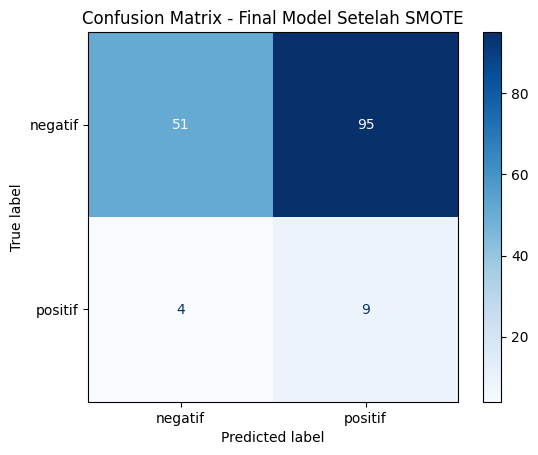

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_final.classes_)

# Tampilkan plot
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Final Model Setelah SMOTE")
plt.show()

### Visualisasi Decision Tree (Final Model)

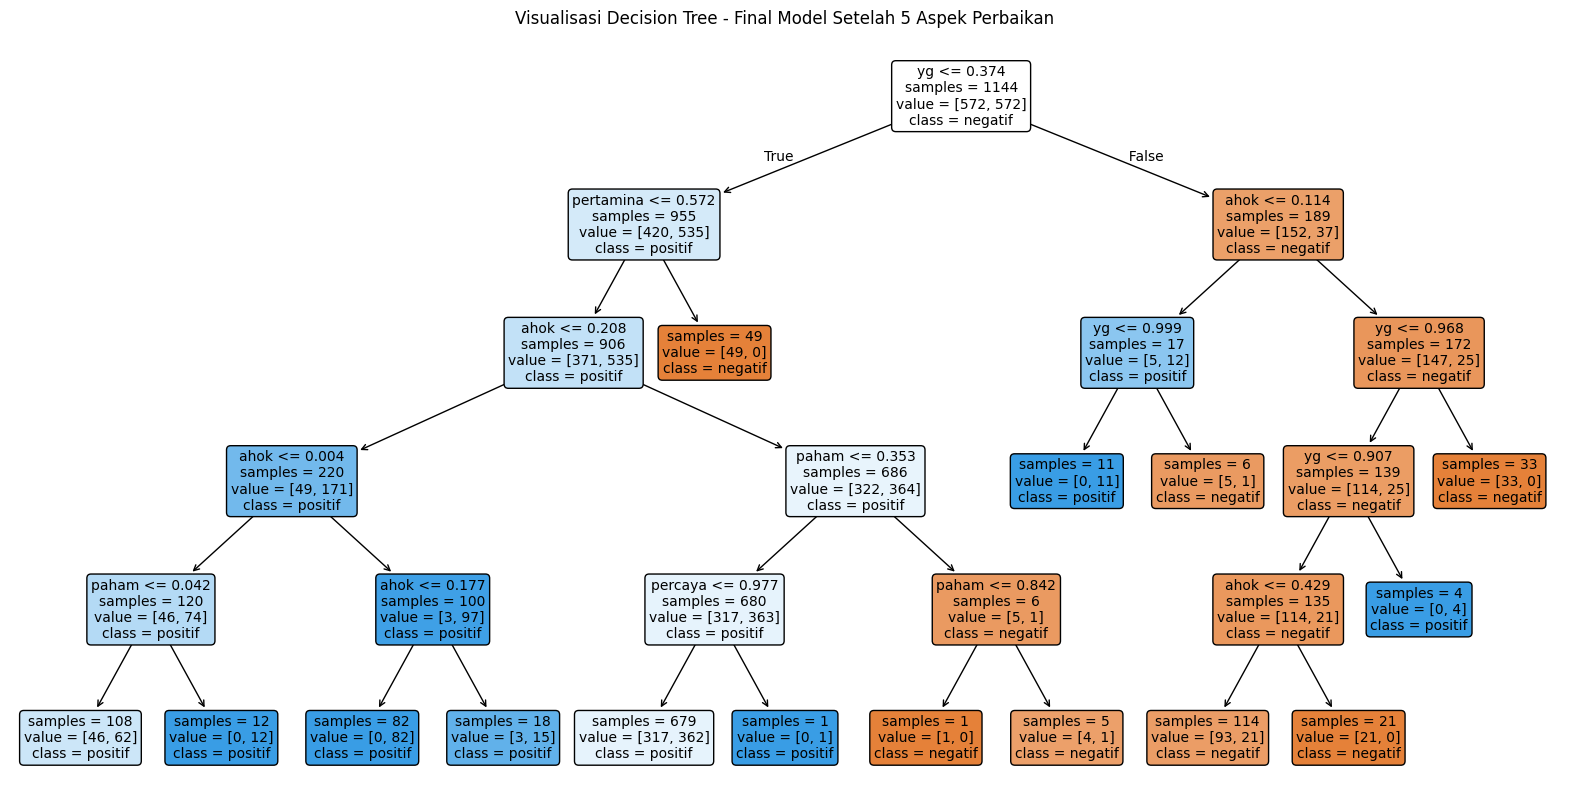

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_final,  # model akhir setelah SMOTE
          filled=True,
          fontsize=10,
          feature_names=important_features,  # dari feature_importances_
          class_names=dt_final.classes_,
          rounded=True,
          impurity=False)
plt.title("Visualisasi Decision Tree - Final Model Setelah 5 Aspek Perbaikan")
plt.show()

# **Visualisasi Hanya sampe Aspek 4 (Akurasi Tertinggi)**

### Confusion Matrix Setelah Aspek 4 (Tanpa SMOTE)

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Prediksi ulang
y_pred_selected = dt_selected.predict(X_test_selected)

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred_selected)
labels = dt_selected.classes_

# Tampilkan sebagai tabel
cm_df = pd.DataFrame(cm, index=[f"Actual: {label}" for label in labels],
                        columns=[f"Predicted: {label}" for label in labels])

print("📊 Confusion Matrix - Setelah Aspek 4 (Feature Selection):\n")
print(cm_df)

📊 Confusion Matrix - Setelah Aspek 4 (Feature Selection):

                 Predicted: negatif  Predicted: positif
Actual: negatif                 145                   1
Actual: positif                  13                   0


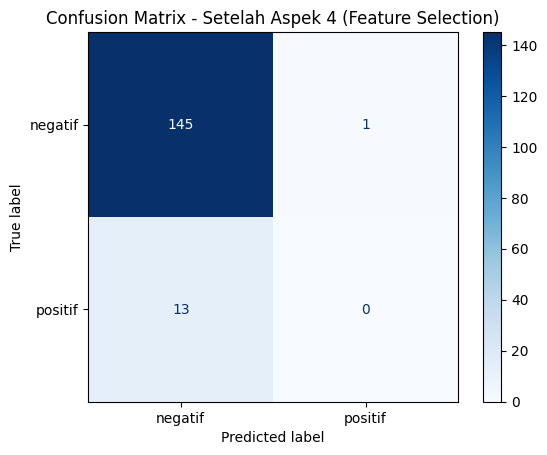

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prediksi ulang dengan model dt_selected
y_pred_selected = dt_selected.predict(X_test_selected)

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred_selected)

# Tampilkan
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=dt_selected.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Setelah Aspek 4 (Feature Selection)")
plt.show()

### Visualisasi Decision Tree Setelah ASPEK 4 (Tanpa SMOTE):

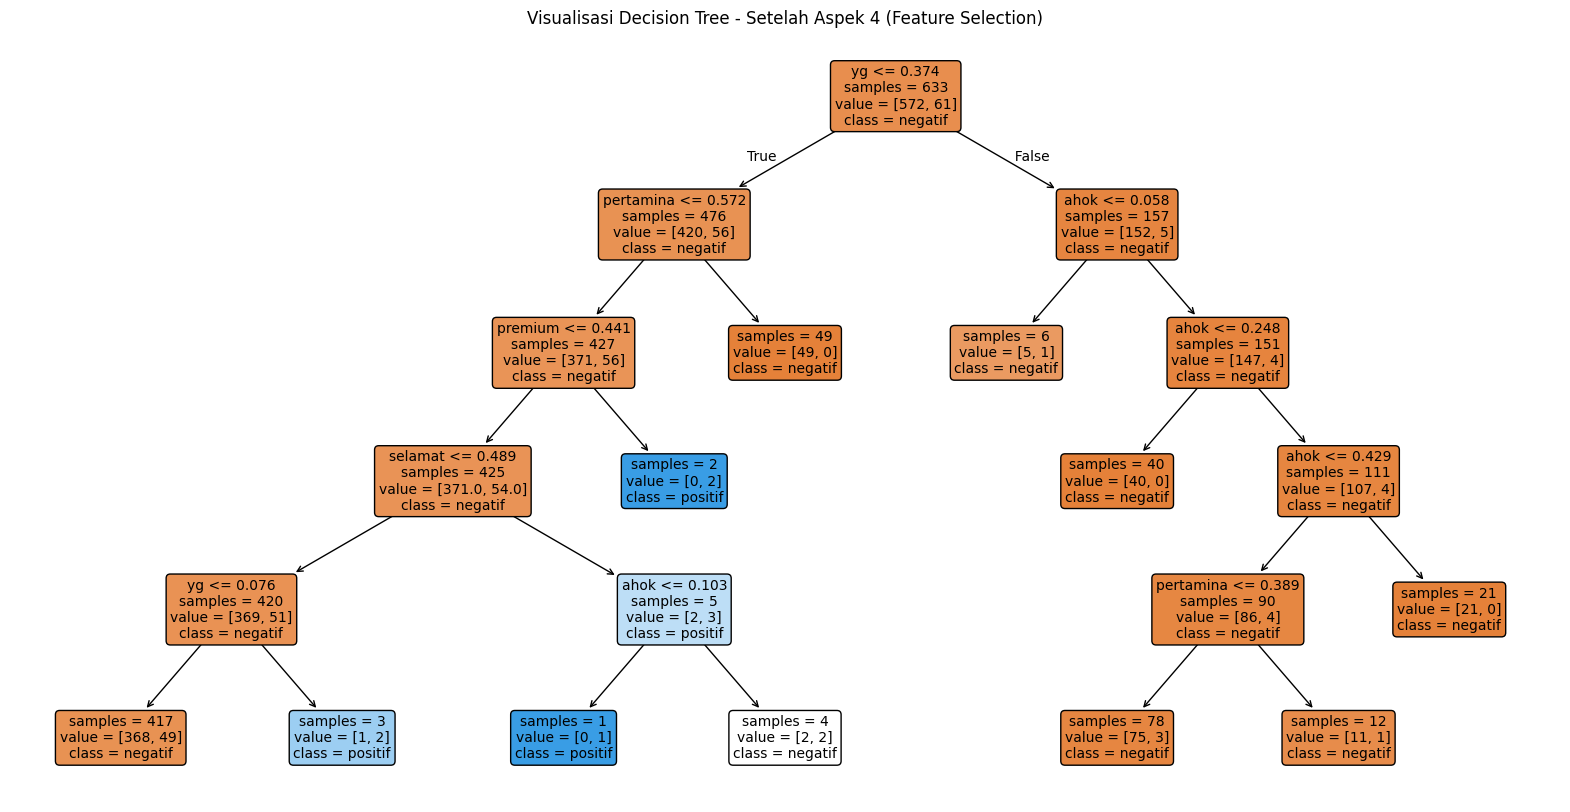

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_selected,  # model setelah feature selection
          filled=True,
          fontsize=10,
          feature_names=important_features,  # fitur penting hasil Aspek 4
          class_names=dt_selected.classes_,
          rounded=True,
          impurity=False)
plt.title("Visualisasi Decision Tree - Setelah Aspek 4 (Feature Selection)")
plt.show()

# **Visualisasi peningkatan akurasi dari Aspek 1 sampai Aspek 5.**

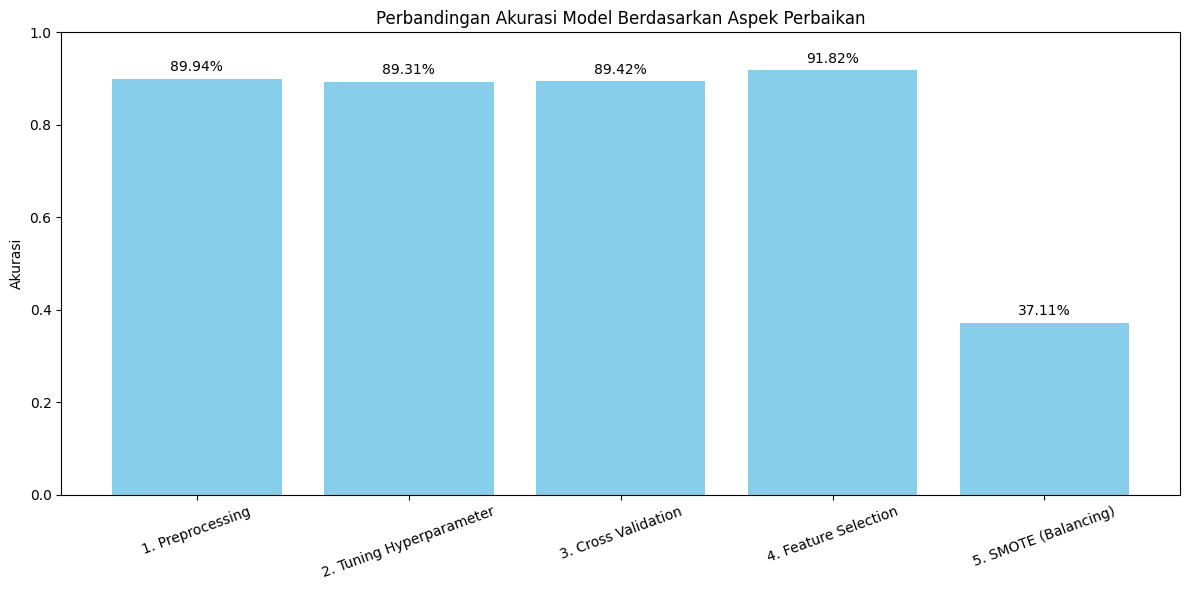

In [ ]:
import matplotlib.pyplot as plt

akurasi_aspek = [
    0.89937106918239,  # Aspek 1
    0.8930817610062893,  # Aspek 2
    0.8941507311586051,  # Aspek 3
    0.9182389937106918,  # Aspek 4
    0.3710691823899371   # Aspek 5
]

aspek_labels = [
    "1. Preprocessing",
    "2. Tuning Hyperparameter",
    "3. Cross Validation",
    "4. Feature Selection",
    "5. SMOTE (Balancing)"
]

plt.figure(figsize=(12, 6))
bars = plt.bar(aspek_labels, akurasi_aspek, color='skyblue')
plt.title("Perbandingan Akurasi Model Berdasarkan Aspek Perbaikan")
plt.ylabel("Akurasi")
plt.ylim(0, 1)

# Tambahkan nilai akurasi di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom')

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# **Word Cloud untuk Tiap Label**

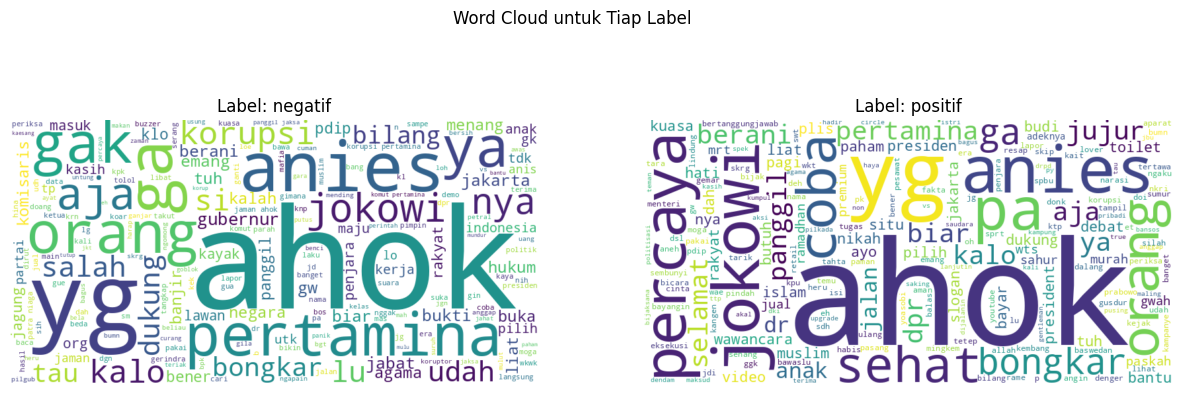

In [ ]:
from wordcloud import WordCloud

labels_unique = df['label'].unique()
plt.figure(figsize=(15, 5))

for i, label in enumerate(labels_unique):
    text = ' '.join(df[df['label'] == label]['processed_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.subplot(1, len(labels_unique), i+1)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Label: {label}")

plt.suptitle("Word Cloud untuk Tiap Label")
plt.show()


# Klasifikasi Dengan Neural Net

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Inisialisasi MLP Classifier
mlp = MLPClassifier(hidden_layer_sizes=(100,),  # 1 hidden layer dengan 100 neuron
                    activation='relu',
                    solver='adam',
                    max_iter=300,
                    random_state=42)

# Latih model dengan data TF-IDF
mlp.fit(X_train_tfidf, y_train)

# Prediksi
y_pred_mlp = mlp.predict(X_test_tfidf)

# Evaluasi
print("✅ Akurasi Neural Network (MLP):", accuracy_score(y_test, y_pred_mlp))
print("\nClassification Report:\n", classification_report(y_test, y_pred_mlp))

✅ Akurasi Neural Network (MLP): 0.9119496855345912

Classification Report:
               precision    recall  f1-score   support

     negatif       0.94      0.97      0.95       146
     positif       0.44      0.31      0.36        13

    accuracy                           0.91       159
   macro avg       0.69      0.64      0.66       159
weighted avg       0.90      0.91      0.90       159



# **Klasifikasi data ahok dg Naive Bayes TF-IDF**

### Import Library

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from google.colab import files

### Dataset

In [ ]:
df = pd.read_csv('ahok_label_with_string (2).csv', sep=';')
print(df.columns)
df = df[['tweet_string', 'label_manual']]
df.columns = ['text', 'label']  # Ubah nama kolom untuk konsistensi

Index(['tweet_clean', 'Tweet_clean', 'tweet_string', 'label_manual'], dtype='object')


In [ ]:
df.head(10)

,text,label
0,'ahok' 'the' 'best' 'mulyono',negatif
1,'ahok' 'utk' 'uji' 'orang' 'ilah' 'jabat' 'yg'...,negatif
2,'ahok' 'yg' 'salah',negatif
3,'jagung' 'dpr' 'kemen' 'bumn' 'panggil' 'aja' ...,negatif
4,'orang' 'yg' 'yg' 'teriak' 'cina' 'kafir' 'aho...,negatif
5,'tidur' 'udah' 'merem' 'pikir' 'kodok' 'balik'...,negatif
6,'abis' 'nonton' 'waktu' 'sahur' 'wkwk' 'gilee'...,negatif
7,'acara' 'cabul' 'si' 'hph' 'dukung' 'bela' 'ko...,negatif
8,'action' 'keluh' 'pidato' 'rakyat' 'bosan' 'ni...,negatif
9,'adeknya' 'ahok',positif


In [ ]:
# Ambil kolom teks dan label
X = df['text']
y = df['label']

### Pembagian Data Training dan Testing

In [ ]:
# Split data menjadi data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Jumlah data latih (X_train): {X_train.shape[0]}")
print(f"Jumlah data uji (X_test): {X_test.shape[0]}")
print(f"Jumlah label latih (y_train): {y_train.shape[0]}")
print(f"Jumlah label uji (y_test): {y_test.shape[0]}")

Jumlah data latih (X_train): 633
Jumlah data uji (X_test): 159
Jumlah label latih (y_train): 633
Jumlah label uji (y_test): 159


In [ ]:
# Vectorisasi Teks TF - IDF
tfidf_vectorizer = TfidfVectorizer()
X_train_vec = tfidf_vectorizer.fit_transform(X_train)
X_test_vec = tfidf_vectorizer.transform(X_test)


### Pemodelan Algoritma Naive Bayes

In [ ]:
# Membuat dan Melatih Model Naive Bayes
model = MultinomialNB()
model.fit(X_train_vec, y_train)

MultinomialNB()

### Akurasi Model

In [ ]:
# Membuat Prediksi
y_pred = model.predict(X_test_vec)

# Evaluasi Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy}")

Akurasi Model: 0.9182389937106918


In [ ]:
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))


Laporan Klasifikasi:
              precision    recall  f1-score   support

     negatif       0.92      1.00      0.96       146
     positif       0.00      0.00      0.00        13

    accuracy                           0.92       159
   macro avg       0.46      0.50      0.48       159
weighted avg       0.84      0.92      0.88       159



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Confussion Matrix

In [ ]:
# Cetak matriks konfusi
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[146   0]
 [ 13   0]]


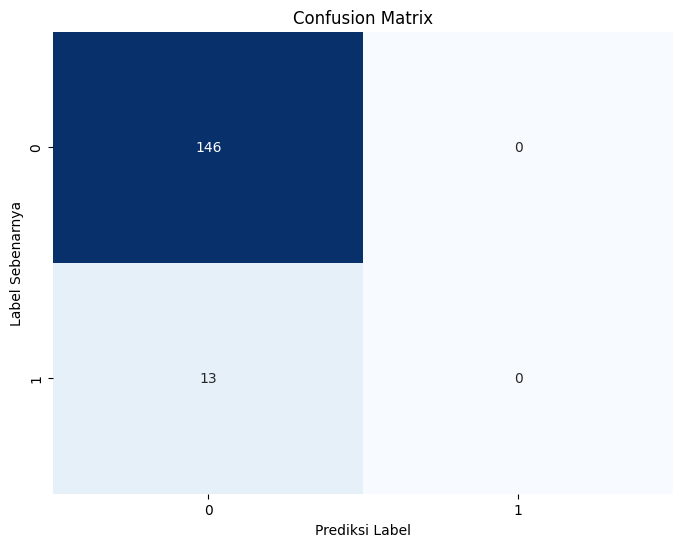

In [ ]:
# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Prediksi Label")
plt.ylabel("Label Sebenarnya")
plt.title("Confusion Matrix")
plt.show()

### Perbaikan Model Naive Bayes menggunakan SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Vectorisasi teks
tfidf_vectorizer = TfidfVectorizer()
X_vec = tfidf_vectorizer.fit_transform(df['text'])
y = df['label']

In [ ]:
# Terapkan SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_vec, y)

In [ ]:
# Split data hasil SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print(f"Jumlah data latih (X_train): {X_train.shape[0]}")
print(f"Jumlah data uji (X_test): {X_test.shape[0]}")
print(f"Jumlah label latih (y_train): {y_train.shape[0]}")
print(f"Jumlah label uji (y_test): {y_test.shape[0]}")

Jumlah data latih (X_train): 1148
Jumlah data uji (X_test): 288
Jumlah label latih (y_train): 1148
Jumlah label uji (y_test): 288


In [ ]:
# Latih model Naive Bayes dengan perbaikan SMOTE
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
# Evaluasi model dengan perbaikan SMOTE
y_pred = model.predict(X_test)
print("Akurasi:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Akurasi: 0.9340277777777778
Confusion Matrix:
[[114  19]
 [  0 155]]
Classification Report:
              precision    recall  f1-score   support

     negatif       1.00      0.86      0.92       133
     positif       0.89      1.00      0.94       155

    accuracy                           0.93       288
   macro avg       0.95      0.93      0.93       288
weighted avg       0.94      0.93      0.93       288



# **Klasifikasi data ahok dg neural network**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from google.colab import files

In [ ]:
df = pd.read_csv('ahok_label_with_string (2).csv', sep=';')
print(df.columns)
df = df[['tweet_string', 'label_manual']]
df.columns = ['text', 'label']  # Ubah nama kolom untuk konsistensi

Index(['tweet_clean', 'Tweet_clean', 'tweet_string', 'label_manual'], dtype='object')


In [ ]:
df.head(10)

,text,label
0,'ahok' 'the' 'best' 'mulyono',negatif
1,'ahok' 'utk' 'uji' 'orang' 'ilah' 'jabat' 'yg'...,negatif
2,'ahok' 'yg' 'salah',negatif
3,'jagung' 'dpr' 'kemen' 'bumn' 'panggil' 'aja' ...,negatif
4,'orang' 'yg' 'yg' 'teriak' 'cina' 'kafir' 'aho...,negatif
5,'tidur' 'udah' 'merem' 'pikir' 'kodok' 'balik'...,negatif
6,'abis' 'nonton' 'waktu' 'sahur' 'wkwk' 'gilee'...,negatif
7,'acara' 'cabul' 'si' 'hph' 'dukung' 'bela' 'ko...,negatif
8,'action' 'keluh' 'pidato' 'rakyat' 'bosan' 'ni...,negatif
9,'adeknya' 'ahok',positif


In [ ]:
# Ambil kolom teks dan label
X = df['text']
y = df['label']

### Split Data Training dan Testing

In [ ]:
# Split data menjadi data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latih (X_train): {X_train.shape[0]}")
print(f"Jumlah data uji (X_test): {X_test.shape[0]}")
print(f"Jumlah label latih (y_train): {y_train.shape[0]}")
print(f"Jumlah label uji (y_test): {y_test.shape[0]}")

Jumlah data latih (X_train): 633
Jumlah data uji (X_test): 159
Jumlah label latih (y_train): 633
Jumlah label uji (y_test): 159


In [ ]:
# Vectorisasi Teks TF - IDF
tfidf_vectorizer = TfidfVectorizer()
X_train_vec = tfidf_vectorizer.fit_transform(X_train)
X_test_vec = tfidf_vectorizer.transform(X_test)


### Membangun Model

In [ ]:
# Bangun model Neural Network
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=300, random_state=42)
model.fit(X_train_vec, y_train) # Use the vectorized training data

MLPClassifier(max_iter=300, random_state=42)

In [ ]:
# 7. Evaluasi model
y_pred = model.predict(X_test_vec)

In [ ]:
# Evaluasi model
y_pred = model.predict(X_test_vec)

print("Akurasi:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Akurasi: 0.9182389937106918
Confusion Matrix:
[[142   4]
 [  9   4]]
Classification Report:
              precision    recall  f1-score   support

     negatif       0.94      0.97      0.96       146
     positif       0.50      0.31      0.38        13

    accuracy                           0.92       159
   macro avg       0.72      0.64      0.67       159
weighted avg       0.90      0.92      0.91       159



### Menerapkan SMOTE untuk Menangani Ketidakseimbangan Kelas

Karena data Anda mungkin tidak seimbang, kita akan menggunakan SMOTE (Synthetic Minority Over-sampling Technique) untuk membuat sampel sintetis dari kelas minoritas. Ini dapat membantu meningkatkan kinerja model pada kelas minoritas.

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier # Import MLPClassifier

# Terapkan SMOTE pada data latih yang sudah divetorisasi
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_vec, y_train)

print(f"Jumlah data latih setelah SMOTE (X_train_resampled): {X_train_resampled.shape[0]}")
print(f"Jumlah label latih setelah SMOTE (y_train_resampled): {y_train_resampled.shape[0]}")

Jumlah data latih setelah SMOTE (X_train_resampled): 1144
Jumlah label latih setelah SMOTE (y_train_resampled): 1144


In [ ]:
from sklearn.neural_network import MLPClassifier # Import MLPClassifier

# Bangun model Neural Network dengan data yang sudah di-SMOTE
model_smote = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=300, random_state=42)
model_smote.fit(X_train_resampled, y_train_resampled) # Gunakan data latih yang sudah di-SMOTE

MLPClassifier(max_iter=300, random_state=42)

### Evaluasi Model yang Dilatih dengan SMOTE

In [ ]:
# Evaluasi model yang dilatih dengan SMOTE
y_pred_smote = model_smote.predict(X_test_vec)

print("Akurasi (dengan SMOTE):", accuracy_score(y_test, y_pred_smote))
print("Confusion Matrix (dengan SMOTE):")
print(confusion_matrix(y_test, y_pred_smote))
print("Classification Report (dengan SMOTE):")
print(classification_report(y_test, y_pred_smote))

Akurasi (dengan SMOTE): 0.89937106918239
Confusion Matrix (dengan SMOTE):
[[137   9]
 [  7   6]]
Classification Report (dengan SMOTE):
              precision    recall  f1-score   support

     negatif       0.95      0.94      0.94       146
     positif       0.40      0.46      0.43        13

    accuracy                           0.90       159
   macro avg       0.68      0.70      0.69       159
weighted avg       0.91      0.90      0.90       159

